In [19]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt

from src.core.data.rainforest_connection import RainforestConnection
from src.core.data.soundscape_embeddings import SoundscapeEmbeddingsDataModule
from src.core.transforms.translation import translation_1d as translation
from src.core.models.sivae import SIVAE
from src.core.models.vae import VAE
from src.core.models.mil_species_detector import MILSpeciesDetector
from src.core.utils.sketch import make_ax_invisible

plt.rcParams.update({
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.titlesize': 8, 
    'figure.titlesize': 10,
})

def wrap_sentence(sentence, max_length):
    words = sentence.split()
    lines = []
    current_line = ""
    for word in words:
        if len(current_line) + len(word) + (1 if current_line else 0) <= max_length:
            if current_line:
                current_line += " " 
            current_line += word
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    return "\n".join(lines)


model_path = pathlib.Path("/its/home/kag25/models/v4")
data = RainforestConnection("/its/home/kag25/data/rainforest_connection")
save_dir = pathlib.Path("/its/home/kag25/experiments/v4/plots/")
save_dir.mkdir(exist_ok=True, parents=True)

In [2]:
model_class = "vae"
vae_model_name = "jumpy-engine"
clf_model_name = "inhale-judge"
vae = VAE.load_from_checkpoint(model_path / model_class / vae_model_name / "step=180000.ckpt", map_location="cuda").eval()
vae_clf = MILSpeciesDetector.load_from_checkpoint(model_path / "species_detectors" / f"{vae_model_name}_RFCX_bird.ckpt", map_location="cuda").eval()
vae_scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/test_scores.parquet/model_{vae_model_name}_run_id={clf_model_name}.parquet")
vae_scores.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,attention,classifiers,clf_regulariser,attn_regulariser,beta,gamma_clf,gamma_attn,label_smoothing,clf_learning_rate,attn_learning_rate
0,Patagioenas squamosa_Scaly-naped Pigeon,0.095644,0.973799,30,inhale-judge,jumpy-engine,RFCX_bird,8,None,None,None,None,0.0,0.001,0.001,0.0,0.01,0.001
1,Spindalis portoricensis_Puerto Rican Spindalis,0.334547,0.806136,58,inhale-judge,jumpy-engine,RFCX_bird,8,None,None,None,None,0.0,0.001,0.001,0.0,0.01,0.001
2,Gymnasio nudipes_Puerto Rican Owl,0.099405,0.890840,33,inhale-judge,jumpy-engine,RFCX_bird,8,None,None,None,None,0.0,0.001,0.001,0.0,0.01,0.001
3,Melanerpes portoricensis_Puerto Rican Woodpecker,0.053032,0.857386,32,inhale-judge,jumpy-engine,RFCX_bird,8,None,None,None,None,0.0,0.001,0.001,0.0,0.01,0.001
4,Melopyrrha portoricensis_Puerto Rican Bullfinch,0.035240,0.795963,32,inhale-judge,jumpy-engine,RFCX_bird,8,None,None,None,None,0.0,0.001,0.001,0.0,0.01,0.001


In [3]:
model_class = "sivae"
sivae_model_name = "earthy-virgo"
clf_model_name = "dazzling-albert"
sivae = SIVAE.load_from_checkpoint(model_path / model_class / sivae_model_name / "step=180000.ckpt", map_location="cuda").eval()
sivae_clf = MILSpeciesDetector.load_from_checkpoint(model_path / "species_detectors" / f"{sivae_model_name}_RFCX_bird.ckpt", map_location="cuda").eval()
sivae_scores = pd.read_parquet(f"/its/home/kag25/experiments/v4/species_detectors/test_scores.parquet/model_{sivae_model_name}_run_id={clf_model_name}.parquet")
sivae_scores.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,species_name,AP,auROC,train_label_counts,run_id,model,scope,seed,attention,classifiers,clf_regulariser,attn_regulariser,beta,gamma_clf,gamma_attn,label_smoothing,clf_learning_rate,attn_learning_rate
0,Melopyrrha portoricensis_Puerto Rican Bullfinch,0.350750,0.924894,32,dazzling-albert,earthy-virgo,RFCX_bird,8,None,None,None,None,0.0,0.001,0.001,0.0,0.05,0.0005
1,Coccyzus vieilloti_Puerto Rican Lizard-Cuckoo,0.380981,0.898862,22,dazzling-albert,earthy-virgo,RFCX_bird,8,None,None,None,None,0.0,0.001,0.001,0.0,0.05,0.0005
2,Vireo altiloquus_Black-whiskered Vireo,0.174319,0.887432,38,dazzling-albert,earthy-virgo,RFCX_bird,8,None,None,None,None,0.0,0.001,0.001,0.0,0.05,0.0005
3,Margarops fuscatus_Pearly-eyed Thrasher,0.048134,0.775655,27,dazzling-albert,earthy-virgo,RFCX_bird,8,None,None,None,None,0.0,0.001,0.001,0.0,0.05,0.0005
4,Coereba flaveola_Bananaquit,0.068695,0.910636,33,dazzling-albert,earthy-virgo,RFCX_bird,8,None,None,None,None,0.0,0.001,0.001,0.0,0.05,0.0005


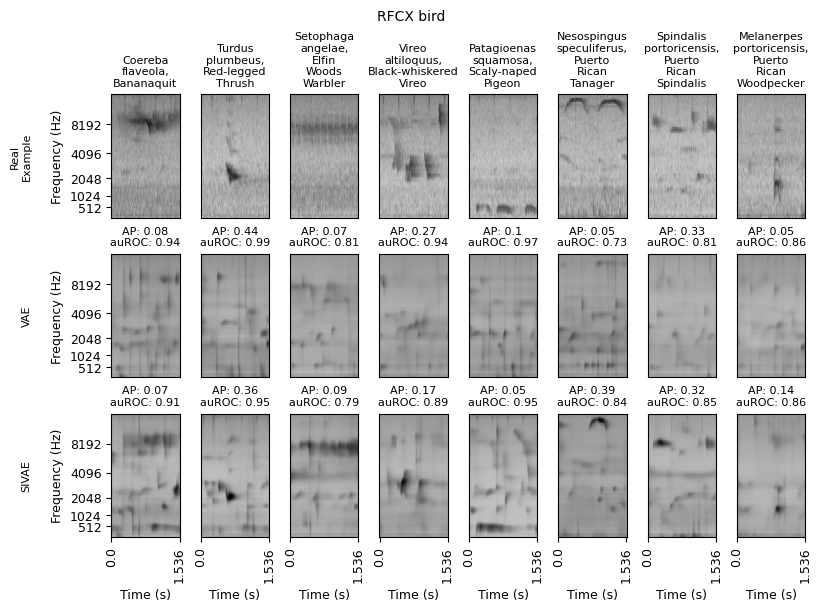

In [17]:
species_params = [ 
    { "species_name": "Coereba flaveola_Bananaquit", "file_name": "train/0a9cdd8a5.flac", "t_start_seconds": 49.2},
    { "species_name": "Turdus plumbeus_Red-legged Thrush", "file_name": "train/9cb1f4a34.flac", "t_start_seconds": 28.8},
    { "species_name": "Setophaga angelae_Elfin Woods Warbler", "file_name": "train/88b5c9c1b.flac", "t_start_seconds": 40.5},
    { "species_name": "Vireo altiloquus_Black-whiskered Vireo", "file_name": "train/c4b778e64.flac", "t_start_seconds": 28.25},
    { "species_name": "Patagioenas squamosa_Scaly-naped Pigeon", "file_name": "train/21e2f2977.flac", "t_start_seconds": 23},
    { "species_name": "Nesospingus speculiferus_Puerto Rican Tanager", "file_name": "train/1702d35a0.flac", "t_start_seconds": 29.1},
    { "species_name": "Spindalis portoricensis_Puerto Rican Spindalis", "file_name": "train/16553d5cd.flac", "t_start_seconds": 33.5},
    { "species_name": "Melanerpes portoricensis_Puerto Rican Woodpecker", "file_name": "train/745171bf2.flac", "t_start_seconds": 4.5},
]   

fig, axes = plt.subplots(
    nrows=3,
    ncols=len(species_params) + 1,
    figsize=(8.1, 6),
    width_ratios=[0.01, *[0.95 / (len(species_params)) for _ in range(len(species_params))]],
    constrained_layout=True,
)
vmax, vmin = 25, -60
hops_per_second = 48_000 / 384
frame_length_seconds = 192 / hops_per_second
frame_length_hops = 192

model_means = {}
for j, (model_name, vae, clf) in enumerate([(vae_model_name, vae, vae_clf), (sivae_model_name, sivae, sivae_clf)]):
    dm = SoundscapeEmbeddingsDataModule(root=f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/RFCX_bird").setup()
    z_mean = dm.train_data.features.iloc[:, range(128)].mean()
    model_means[j] = torch.tensor(z_mean, dtype=torch.float32, device="cuda").unsqueeze(0).unsqueeze(0)

model_params = {
    "vae": {
        "Coereba flaveola_Bananaquit": {"delta": 25, "shift": 0.0},
        "Turdus plumbeus_Red-legged Thrush": {"delta": 25, "shift": 0.0},
        "Setophaga angelae_Elfin Woods Warbler": {"delta": 25, "shift": 0.0},
        "Vireo altiloquus_Black-whiskered Vireo": {"delta": 25, "shift": 0.0},
        "Patagioenas squamosa_Scaly-naped Pigeon": {"delta": 25, "shift": 0.0},
        "Nesospingus speculiferus_Puerto Rican Tanager": {"delta": 25, "shift": 0.0},
        "Spindalis portoricensis_Puerto Rican Spindalis": {"delta": 25, "shift": 0.0},
        "Melanerpes portoricensis_Puerto Rican Woodpecker": {"delta": 25, "shift": 0.0},
    },
    "sivae": {
        "Coereba flaveola_Bananaquit": {"delta": 20, "shift": 0.0},
        "Turdus plumbeus_Red-legged Thrush": {"delta": 20, "shift": -0.5},
        "Setophaga angelae_Elfin Woods Warbler": {"delta": 20, "shift": 0.0},
        "Vireo altiloquus_Black-whiskered Vireo": {"delta": 20, "shift": -0.5},
        "Patagioenas squamosa_Scaly-naped Pigeon": {"delta": 20, "shift": 0.0},
        "Nesospingus speculiferus_Puerto Rican Tanager": {"delta": 20, "shift": 0.0},
        "Spindalis portoricensis_Puerto Rican Spindalis": {"delta": 20, "shift": 0.0},
        "Melanerpes portoricensis_Puerto Rican Woodpecker": {"delta": 20, "shift": 0.0},
    },
}
with torch.no_grad():
    for i, params in enumerate(species_params):
        species_name, file_name, t_start_seconds = params.values()
        if i == 0:
            title_ax = axes[0, 0]
            title_ax.set_ylabel("Real\nExample", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[1, 0]
            title_ax.set_ylabel("VAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[2, 0]
            title_ax.set_ylabel("SIVAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)

        ax = axes[0, i + 1]
        ax.set_title(wrap_sentence(species_name.replace("_", ", "), 10))
        t_start = int(t_start_seconds * hops_per_second)
        t_end = t_start + int(frame_length_seconds * hops_per_second)
        x = vae.front_end(data.load_sample(data.base_dir / file_name).unsqueeze(0).to("cuda")).squeeze()
        x_db = 20 * np.log10(x[:, t_start:t_end].exp().cpu())
        # plot the original
        vae.front_end.plot(x_db, vmax=vmax, vmin=vmin, ax=ax, cmap="Greys")
        ax.tick_params(labelbottom=False, bottom=False)
        ax.set_xlabel("")
        
        for j, (model_class, vae, clf, scores) in enumerate([("vae", vae, vae_clf, vae_scores), ("sivae", sivae, sivae_clf, sivae_scores)]):
            delta, shift = model_params[model_class][species_name].values()
            ap, auroc = scores[scores.species_name == species_name][["AP", "auROC"]].iloc[0].to_dict().values()
            z = model_means[j]
            W = clf.species_weights(species_name)
            norm = torch.linalg.norm(W)
            z_tilde = z + ((z @ W.T / norm) + delta) * (W / norm)
            x_tilde = vae.decode(z_tilde, shift * torch.ones(1, 1, 1, device=z.device)).cpu().squeeze().t()
            x_tilde_db = 20 * np.log10(x_tilde.exp())
            ax = axes[j + 1, i + 1]
            vae.front_end.plot(x_tilde_db, vmax=vmax, vmin=vmin, cmap="Greys", ax=ax)
            ax.tick_params(labelbottom=False, bottom=False)
            ax.set_xlabel("")
            ax.set_title(f"AP: {np.format_float_positional(ap, precision=2)}\nauROC: {np.format_float_positional(auroc, precision=2)}")
            
for ax in axes[:, 2:].flatten():
    ax.set_ylabel("")
    ax.tick_params(labelleft=False, left=False)

for ax in axes[-1, 1:].flatten():
    ax.tick_params(labelbottom=True, bottom=True)
    ax.set_xticks([0, 191], [0.0, 1.536], rotation=90)
    ax.set_xlabel("Time (s)")

fig.suptitle("RFCX bird")
fig.savefig(save_dir / "rfcx_bird_interpolation.pdf", format="pdf")
plt.show()

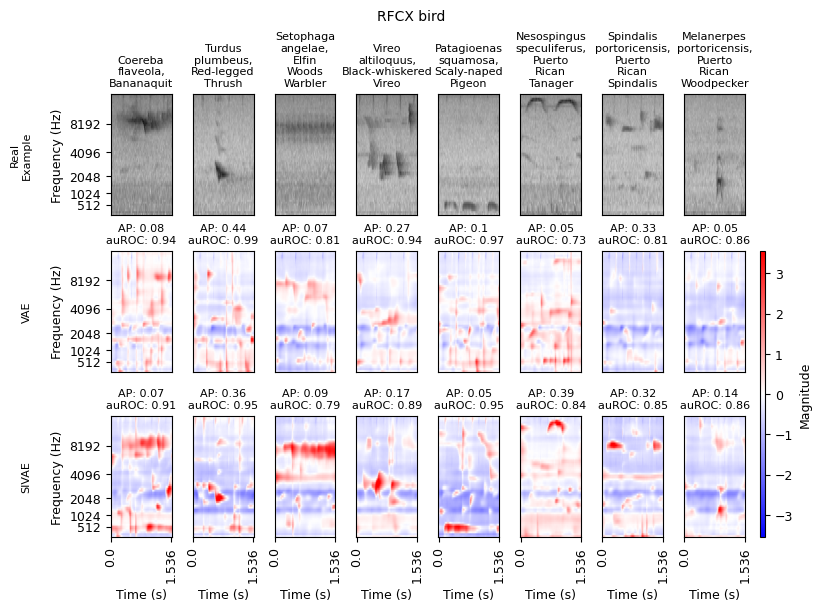

In [18]:
species_params = [ 
    { "species_name": "Coereba flaveola_Bananaquit", "file_name": "train/0a9cdd8a5.flac", "t_start_seconds": 49.2},
    { "species_name": "Turdus plumbeus_Red-legged Thrush", "file_name": "train/9cb1f4a34.flac", "t_start_seconds": 28.8},
    { "species_name": "Setophaga angelae_Elfin Woods Warbler", "file_name": "train/88b5c9c1b.flac", "t_start_seconds": 40.5},
    { "species_name": "Vireo altiloquus_Black-whiskered Vireo", "file_name": "train/c4b778e64.flac", "t_start_seconds": 28.25},
    { "species_name": "Patagioenas squamosa_Scaly-naped Pigeon", "file_name": "train/21e2f2977.flac", "t_start_seconds": 23},
    { "species_name": "Nesospingus speculiferus_Puerto Rican Tanager", "file_name": "train/1702d35a0.flac", "t_start_seconds": 29.1},
    { "species_name": "Spindalis portoricensis_Puerto Rican Spindalis", "file_name": "train/16553d5cd.flac", "t_start_seconds": 33.5},
    { "species_name": "Melanerpes portoricensis_Puerto Rican Woodpecker", "file_name": "train/745171bf2.flac", "t_start_seconds": 4.5},
]   


fig = plt.figure(figsize=(8.1, 6), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=len(species_params) + 2, width_ratios=[0.01,*[0.95 / len(species_params) for _ in range(len(species_params))], 0.01,])
axes = np.empty((3, len(species_params) + 2), dtype=object)
for r in range(3):
    for c in range(len(species_params) + 1):
        axes[r, c] = fig.add_subplot(gs[r, c])
axes[0, -1] = fig.add_subplot(gs[0, -1])
axes[0, -1].set_visible(False)
axes[1, -1] = fig.add_subplot(gs[1:, -1])
axes[2, -1] = axes[1, -1]

vmax, vmin = 25, -60
hops_per_second = 48_000 / 384
frame_length_seconds = 192 / hops_per_second
frame_length_hops = 192

model_means = {}
for j, (model_name, vae, clf) in enumerate([(vae_model_name, vae, vae_clf), (sivae_model_name, sivae, sivae_clf)]):
    dm = SoundscapeEmbeddingsDataModule(root=f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/RFCX_bird").setup()
    z_mean = dm.train_data.features.iloc[:, range(128)].mean()
    model_means[j] = torch.tensor(z_mean, dtype=torch.float32, device="cuda").unsqueeze(0).unsqueeze(0)

model_params = {
    "vae": {
        "Coereba flaveola_Bananaquit": {"delta": 25, "shift": 0.0},
        "Turdus plumbeus_Red-legged Thrush": {"delta": 25, "shift": 0.0},
        "Setophaga angelae_Elfin Woods Warbler": {"delta": 25, "shift": 0.0},
        "Vireo altiloquus_Black-whiskered Vireo": {"delta": 25, "shift": 0.0},
        "Patagioenas squamosa_Scaly-naped Pigeon": {"delta": 25, "shift": 0.0},
        "Nesospingus speculiferus_Puerto Rican Tanager": {"delta": 25, "shift": 0.0},
        "Spindalis portoricensis_Puerto Rican Spindalis": {"delta": 25, "shift": 0.0},
        "Melanerpes portoricensis_Puerto Rican Woodpecker": {"delta": 25, "shift": 0.0},
    },
    "sivae": {
        "Coereba flaveola_Bananaquit": {"delta": 20, "shift": 0.0},
        "Turdus plumbeus_Red-legged Thrush": {"delta": 20, "shift": -0.5},
        "Setophaga angelae_Elfin Woods Warbler": {"delta": 20, "shift": 0.0},
        "Vireo altiloquus_Black-whiskered Vireo": {"delta": 20, "shift": -0.5},
        "Patagioenas squamosa_Scaly-naped Pigeon": {"delta": 20, "shift": 0.0},
        "Nesospingus speculiferus_Puerto Rican Tanager": {"delta": 20, "shift": 0.0},
        "Spindalis portoricensis_Puerto Rican Spindalis": {"delta": 20, "shift": 0.0},
        "Melanerpes portoricensis_Puerto Rican Woodpecker": {"delta": 20, "shift": 0.0},
    },
}

residuals = []
rmin, rmax = np.inf, -np.inf
with torch.no_grad():
    for i, params in enumerate(species_params):
        rmin, rmax = np.inf, -np.inf
        species_residuals = []
        species_name, file_name, t_start_seconds = params.values()
        if i == 0:
            title_ax = axes[0, 0]
            title_ax.set_ylabel("Real\nExample", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[1, 0]
            title_ax.set_ylabel("VAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)
            title_ax = axes[2, 0]
            title_ax.set_ylabel("SIVAE", fontsize=plt.rcParams['axes.titlesize'])
            make_ax_invisible(title_ax)

        ax = axes[0, i + 1]
        ax.set_title(wrap_sentence(species_name.replace("_", ", "), 10))
        t_start = int(t_start_seconds * hops_per_second)
        t_end = t_start + int(frame_length_seconds * hops_per_second)
        x = vae.front_end(data.load_sample(data.base_dir / file_name).unsqueeze(0).to("cuda")).squeeze()
        x_db = 20 * np.log10(x[:, t_start:t_end].exp().cpu())
        # plot the original
        vae.front_end.plot(x_db, vmax=vmax, vmin=vmin, ax=ax, cmap="Greys")
        ax.tick_params(labelbottom=False, bottom=False)
        ax.set_xlabel("")
        
        for j, (model_class, vae, clf, scores) in enumerate([("vae", vae, vae_clf, vae_scores), ("sivae", sivae, sivae_clf, sivae_scores)]):
            delta, shift = model_params[model_class][species_name].values()
            z = model_means[j]
            x0 =  vae.decode(z, torch.zeros(1, 1, 1, device=z.device)).cpu().squeeze().t()
            W = clf.species_weights(species_name)
            norm = torch.linalg.norm(W)
            z_tilde = z + ((z @ W.T / norm) + delta) * (W / norm)
            x_tilde = vae.decode(z_tilde, shift * torch.ones(1, 1, 1, device=z.device)).cpu().squeeze().t()
            # (x_tilde - x)
            # x_tilde_db = 20 * np.log10(x_tilde.exp())
            x_res = (x_tilde - x0)
            rmin = min(rmin, x_res.min())
            rmax = max(rmax, x_res.max())
            species_residuals.append(x_res)
        residuals.append(species_residuals)

for i, params in enumerate(species_params):
    species_name, file_name, t_start_seconds = params.values()
    for j, (model_class, vae, clf, scores) in enumerate([("vae", vae, vae_clf, vae_scores), ("sivae", sivae, sivae_clf, sivae_scores)]):
        ax = axes[j + 1, i + 1]
        ap, auroc = scores[scores.species_name == species_name][["AP", "auROC"]].iloc[0].to_dict().values()
        residual = residuals[i][j]
        bound = max(np.abs(rmin), np.abs(rmax))
        mesh = vae.front_end.plot(residual, cmap="bwr", vmin=-bound, vmax=bound, ax=ax)
        ax.tick_params(labelbottom=False, bottom=False)
        ax.set_xlabel("")
        ax.set_title(f"AP: {np.format_float_positional(ap, precision=2)}\nauROC: {np.format_float_positional(auroc, precision=2)}")
            
for ax in axes[:, 2:-1].flatten():
    ax.set_ylabel("")
    ax.tick_params(labelleft=False, left=False)

for ax in axes[-1, 1:-1].flatten():
    ax.tick_params(labelbottom=True, bottom=True)
    ax.set_xticks([0, 191], [0.0, 1.536], rotation=90)
    ax.set_xlabel("Time (s)")
    
cbar = fig.colorbar(mesh, cax=axes[1, -1])
cbar.set_label("Magnitude")

fig.suptitle("RFCX bird")
fig.savefig(save_dir / "rfcx_bird_interpolation_residual.pdf", format="pdf")
plt.show()

In [26]:
save_dir = root / "docs" / "assets" / "images" / "frames_rerun"
save_dir.mkdir(exist_ok=True, parents=True)

plt.rcParams.update({
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.titlesize': 10, 
    'figure.titlesize': 10,
})

species_params = [ 
    { "species_name": "Coereba flaveola_Bananaquit", "file_name": "train/0a9cdd8a5.flac", "t_start_seconds": 49.2},
    { "species_name": "Turdus plumbeus_Red-legged Thrush", "file_name": "train/9cb1f4a34.flac", "t_start_seconds": 28.8},
    { "species_name": "Setophaga angelae_Elfin Woods Warbler", "file_name": "train/88b5c9c1b.flac", "t_start_seconds": 40.5},
    { "species_name": "Vireo altiloquus_Black-whiskered Vireo", "file_name": "train/c4b778e64.flac", "t_start_seconds": 28.25},
    { "species_name": "Patagioenas squamosa_Scaly-naped Pigeon", "file_name": "train/21e2f2977.flac", "t_start_seconds": 23},
    { "species_name": "Nesospingus speculiferus_Puerto Rican Tanager", "file_name": "train/1702d35a0.flac", "t_start_seconds": 29.1},
    { "species_name": "Spindalis portoricensis_Puerto Rican Spindalis", "file_name": "train/16553d5cd.flac", "t_start_seconds": 33.5},
    { "species_name": "Melanerpes portoricensis_Puerto Rican Woodpecker", "file_name": "train/745171bf2.flac", "t_start_seconds": 4.5},
]   

vmax, vmin = 25, -60
hops_per_second = 48_000 / 384
frame_length_seconds = 192 / hops_per_second
frame_length_hops = 192

j = 0
model_means = {}
model_name, vae, clf = sivae_model_name, sivae, sivae_clf
dm = SoundscapeEmbeddingsDataModule(root=f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/RFCX_bird").setup()
z_mean = dm.train_data.features.iloc[:, range(128)].mean()
model_means[j] = torch.tensor(z_mean, dtype=torch.float32, device="cuda").unsqueeze(0).unsqueeze(0)

model_params = {
    "vae": {
        "Coereba flaveola_Bananaquit": {"delta": 25, "shift": 0.0},
        "Turdus plumbeus_Red-legged Thrush": {"delta": 25, "shift": 0.0},
        "Setophaga angelae_Elfin Woods Warbler": {"delta": 25, "shift": 0.0},
        "Vireo altiloquus_Black-whiskered Vireo": {"delta": 25, "shift": 0.0},
        "Patagioenas squamosa_Scaly-naped Pigeon": {"delta": 25, "shift": 0.0},
        "Nesospingus speculiferus_Puerto Rican Tanager": {"delta": 25, "shift": 0.0},
        "Spindalis portoricensis_Puerto Rican Spindalis": {"delta": 25, "shift": 0.0},
        "Melanerpes portoricensis_Puerto Rican Woodpecker": {"delta": 25, "shift": 0.0},
    },
    "sivae": {
        "Coereba flaveola_Bananaquit": {"delta": 20, "shift": 0.0},
        "Turdus plumbeus_Red-legged Thrush": {"delta": 20, "shift": -0.5},
        "Setophaga angelae_Elfin Woods Warbler": {"delta": 20, "shift": 0.0},
        "Vireo altiloquus_Black-whiskered Vireo": {"delta": 20, "shift": -0.5},
        "Patagioenas squamosa_Scaly-naped Pigeon": {"delta": 20, "shift": 0.0},
        "Nesospingus speculiferus_Puerto Rican Tanager": {"delta": 20, "shift": 0.0},
        "Spindalis portoricensis_Puerto Rican Spindalis": {"delta": 20, "shift": 0.0},
        "Melanerpes portoricensis_Puerto Rican Woodpecker": {"delta": 20, "shift": 0.0},
    },
}

with torch.no_grad():
    for i, params in enumerate(species_params):
        species_name, file_name, t_start_seconds = params.values()
        common_name = species_name.split("_")[1]
        t_start = int(t_start_seconds * hops_per_second)
        t_end = t_start + int(frame_length_seconds * hops_per_second)
        x = vae.front_end(data.load_sample(data.base_dir / file_name).unsqueeze(0).to("cuda")).squeeze()
        x = x[:, t_start:t_end].exp().cpu()
        x_db = 20 * np.log10(x)
        model_class, vae, clf, scores = ("sivae", sivae, sivae_clf, sivae_scores)

        delta_max, shift = model_params[model_class][species_name].values()
        z0 = model_means[j]
        x0 =  vae.decode(z, torch.zeros(1, 1, 1, device=z.device)).cpu().squeeze().t()
        species_i = clf.target_names.index(species_name)
        w_mean, w_log_var = clf.classifiers.weight_mu[species_i], clf.classifiers.weight_log_var[species_i]
        W = w_mean
        norm = torch.linalg.norm(W)
        for k, delta in enumerate(torch.linspace(0, delta_max, 20)):
            fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(7, 4), constrained_layout=True)
            vae.front_end.plot(x_db, vmax=vmax, vmin=vmin, cmap="Greys", ax=ax1)
            ax1.set_title("Exemplar Call")
            z_tilde = z0 + ((z @ W.T / norm) + delta) * (W / norm)
            x_tilde = vae.decode(z_tilde, shift * torch.ones(1, 1, 1, device=z.device)).squeeze().t()
            x_tilde = x_tilde.exp().cpu()
            x_tilde_db = 20 * np.log10(x_tilde)
            vae.front_end.plot(x_tilde_db, vmax=vmax, vmin=vmin, cmap="Greys", ax=ax2)
            ax2.set_title("Basis of Detection")
            ax1.set_xticks([0, 191], [0.0, 1.536], rotation=90)
            ax2.set_xticks([0, 191], [0.0, 1.536], rotation=90)
            fig.savefig(save_dir / f"{common_name}_{k}")
            plt.close()